# UK House Price Fluctuation Prediction
**Dataset:** 2015–2025 | 12 UK Regions | 4 Property Types  
**Target:** Predict Average House Price (GBP)

## 1. Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

print('All imports successful.')

All imports successful.


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('uk_house_prices_raw.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (6336, 10)


,RecordID,Date,Year,Month,Region,PropertyType,AveragePrice_GBP,SalesVolume,MedianPrice_GBP,PricePerSqM_GBP
0,1,2015-01,2015,1,London,Detached,752755.0,929,670645.0,9356.0
1,2,2015-01,2015,1,London,Semi-Detached,482220.0,1450,425048.0,4426.0
2,3,2015-01,2015,1,London,Terraced,405345.0,706,361863.0,4978.0
3,4,2015-01,2015,1,London,Flat,356465.0,848,324467.0,4184.0
4,5,2015-02,2015,2,London,Detached,728938.0,862,656372.0,8300.0
5,6,2015-02,2015,2,London,Semi-Detached,472785.0,981,422659.0,5084.0
6,7,2015-02,2015,2,London,Terraced,390011.0,822,359796.0,4817.0
7,8,2015-02,2015,2,London,Flat,343835.0,741,319043.0,3803.0
8,9,2015-03,2015,3,London,Detached,752129.0,964,678284.0,8070.0
9,10,2015-03,2015,3,London,Semi-Detached,468912.0,694,444468.0,4591.0


In [3]:
print('Regions     :', sorted(df['Region'].unique()))
print('PropertyTypes:', sorted(df['PropertyType'].unique()))
print('Year range  :', df['Year'].min(), '-', df['Year'].max())
print('\nNull values:')
print(df.isnull().sum())

Regions     : ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'Northern Ireland', 'Scotland', 'South East', 'South West', 'Wales', 'West Midlands', 'Yorkshire and the Humber']
PropertyTypes: ['Detached', 'Flat', 'Semi-Detached', 'Terraced']
Year range  : 2015 - 2025

Null values:
RecordID            0
Date                0
Year                0
Month               0
Region              0
PropertyType        0
AveragePrice_GBP    0
SalesVolume         0
MedianPrice_GBP     0
PricePerSqM_GBP     0
dtype: int64


In [4]:
df.describe().round(0)

,RecordID,Year,Month,AveragePrice_GBP,SalesVolume,MedianPrice_GBP,PricePerSqM_GBP
count,6336.0,6336.0,6336.0,6336.0,6336.0,6336.0,6336.0
mean,3168.0,2020.0,6.0,284583.0,864.0,260356.0,3115.0
std,1829.0,3.0,3.0,166323.0,235.0,152280.0,1868.0
min,1.0,2015.0,1.0,91814.0,68.0,84546.0,873.0
25%,1585.0,2017.0,4.0,166701.0,703.0,152440.0,1810.0
50%,3168.0,2020.0,6.0,237112.0,850.0,217270.0,2571.0
75%,4752.0,2023.0,9.0,347918.0,1009.0,319552.0,3809.0
max,6336.0,2025.0,12.0,1198626.0,1894.0,1103216.0,15671.0


## 3. Exploratory Data Analysis

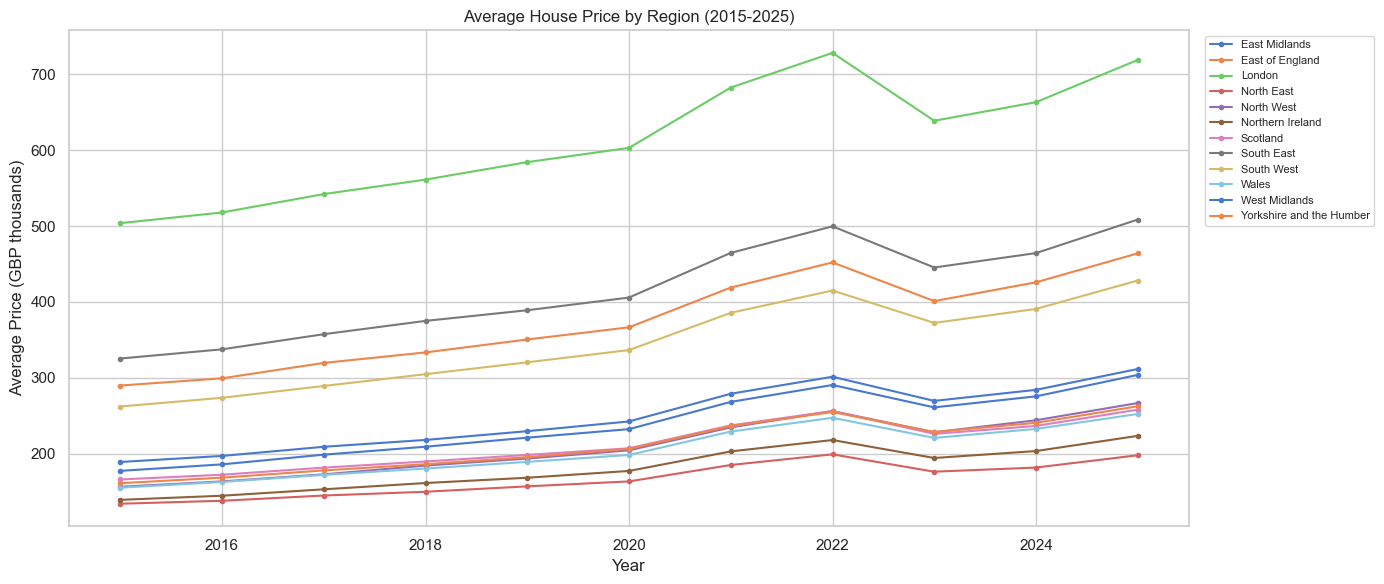

In [5]:
# Average price trend by region
fig, ax = plt.subplots(figsize=(14, 6))
region_trend = df.groupby(['Year', 'Region'])['AveragePrice_GBP'].mean().reset_index()
for region, grp in region_trend.groupby('Region'):
    ax.plot(grp['Year'], grp['AveragePrice_GBP'] / 1000, marker='o', markersize=3, label=region)
ax.set_title('Average House Price by Region (2015-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price (GBP thousands)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/price_by_region.png', dpi=150)
plt.show()

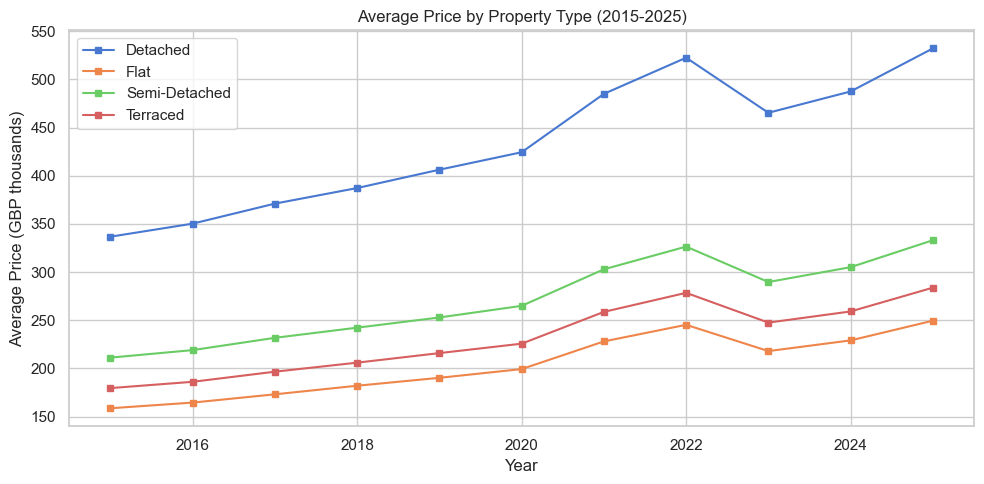

In [6]:
# Property type comparison
fig, ax = plt.subplots(figsize=(10, 5))
ptype_trend = df.groupby(['Year', 'PropertyType'])['AveragePrice_GBP'].mean().reset_index()
for ptype, grp in ptype_trend.groupby('PropertyType'):
    ax.plot(grp['Year'], grp['AveragePrice_GBP'] / 1000, marker='s', markersize=4, label=ptype)
ax.set_title('Average Price by Property Type (2015-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price (GBP thousands)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/price_by_property_type.png', dpi=150)
plt.show()

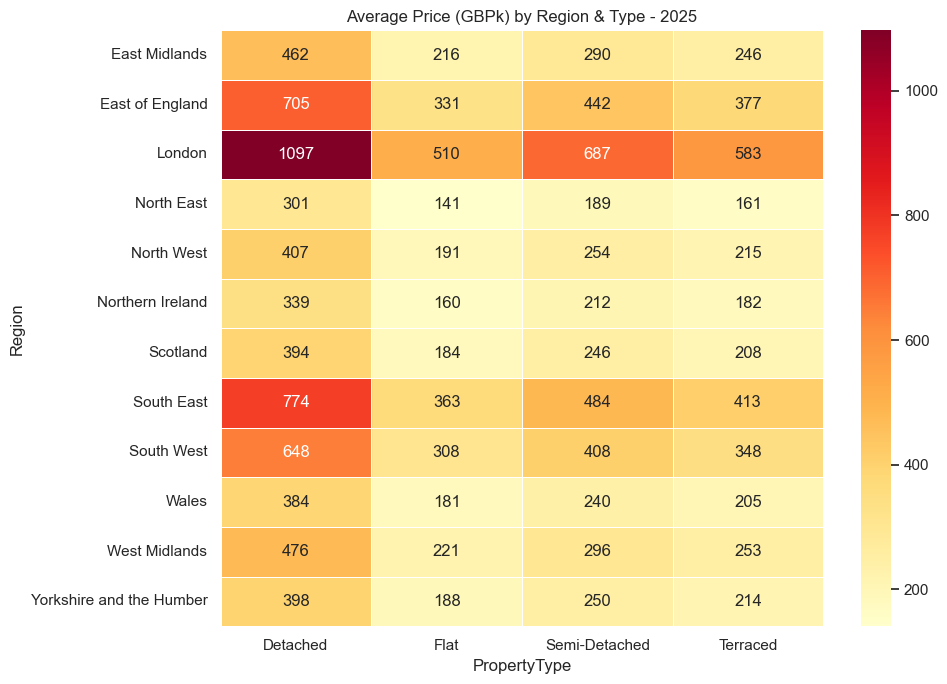

In [7]:
# Heatmap: region x property type (latest year)
latest_year = df['Year'].max()
pivot = (
    df[df['Year'] == latest_year]
    .groupby(['Region', 'PropertyType'])['AveragePrice_GBP']
    .mean().unstack('PropertyType') / 1000
)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title(f'Average Price (GBPk) by Region & Type - {latest_year}')
plt.tight_layout()
plt.savefig('outputs/heatmap_region_type.png', dpi=150)
plt.show()

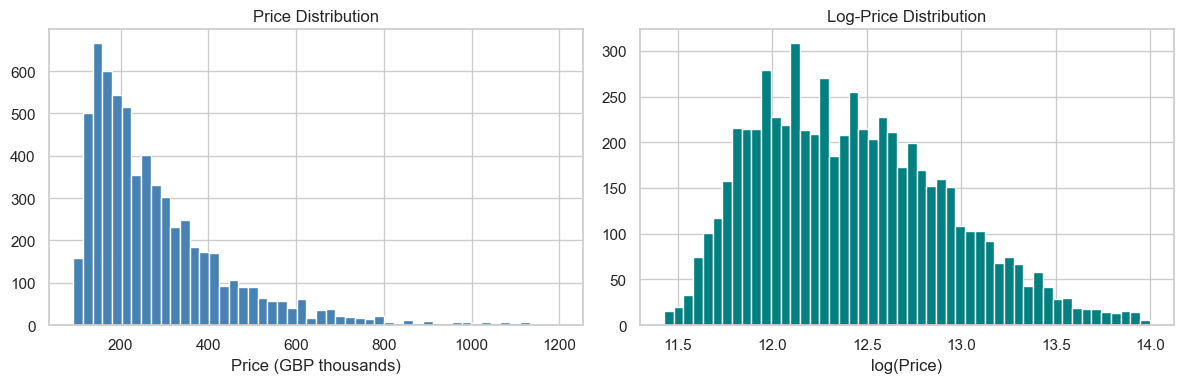

In [8]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['AveragePrice_GBP'] / 1000, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (GBP thousands)')
axes[1].hist(np.log1p(df['AveragePrice_GBP']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Log-Price Distribution')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [9]:
le_region = LabelEncoder()
le_ptype  = LabelEncoder()
df['Region_enc'] = le_region.fit_transform(df['Region'])
df['PType_enc']  = le_ptype.fit_transform(df['PropertyType'])

# Months since Jan 2015 captures long-run trend
df['MonthsSince2015'] = (df['Year'] - 2015) * 12 + df['Month']
df['Quarter'] = ((df['Month'] - 1) // 3) + 1

FEATURES = ['Year', 'Month', 'Quarter', 'MonthsSince2015',
            'Region_enc', 'PType_enc', 'SalesVolume']
TARGET = 'AveragePrice_GBP'

X = df[FEATURES]
y = df[TARGET]
print('Features:', FEATURES)
print('Target  :', TARGET)
X.head()

Features: ['Year', 'Month', 'Quarter', 'MonthsSince2015', 'Region_enc', 'PType_enc', 'SalesVolume']
Target  : AveragePrice_GBP


,Year,Month,Quarter,MonthsSince2015,Region_enc,PType_enc,SalesVolume
0,2015,1,1,1,2,0,929
1,2015,1,1,1,2,2,1450
2,2015,1,1,1,2,3,706
3,2015,1,1,1,2,1,848
4,2015,2,1,2,2,0,862


## 5. Train / Test Split (Temporal)

In [10]:
# Last 18 months as test set — avoids future data leaking into training
cutoff = df['MonthsSince2015'].max() - 18
train_mask = df['MonthsSince2015'] <= cutoff

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')
print(f'Test period covers the last 18 months of data')

Train: 5,472 rows  |  Test: 864 rows
Test period covers the last 18 months of data


## 6. Model Training & Evaluation

In [11]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0)),
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=4,
        n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        min_samples_leaf=4, subsample=0.8, random_state=42
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model, 'preds': preds}
    print(f'{name}')
    print(f'  MAE : GBP {mae:,.0f}  |  RMSE: GBP {rmse:,.0f}  |  R2: {r2:.4f}\n')

Linear Regression
  MAE : GBP 124,426  |  RMSE: GBP 167,603  |  R2: 0.1875

Ridge Regression
  MAE : GBP 124,404  |  RMSE: GBP 167,613  |  R2: 0.1874



Random Forest
  MAE : GBP 40,176  |  RMSE: GBP 46,227  |  R2: 0.9382



Gradient Boosting
  MAE : GBP 38,048  |  RMSE: GBP 44,391  |  R2: 0.9430



In [12]:
# Summary table
summary = pd.DataFrame({
    n: {'MAE (GBP)': f"{v['MAE']:,.0f}", 'RMSE (GBP)': f"{v['RMSE']:,.0f}", 'R2': f"{v['R2']:.4f}"}
    for n, v in results.items()
}).T
summary

,MAE (GBP),RMSE (GBP),R2
Linear Regression,"124,426","167,603",0.1875
Ridge Regression,"124,404","167,613",0.1874
Random Forest,"40,176","46,227",0.9382
Gradient Boosting,"38,048","44,391",0.9430


## 7. Visualise Results

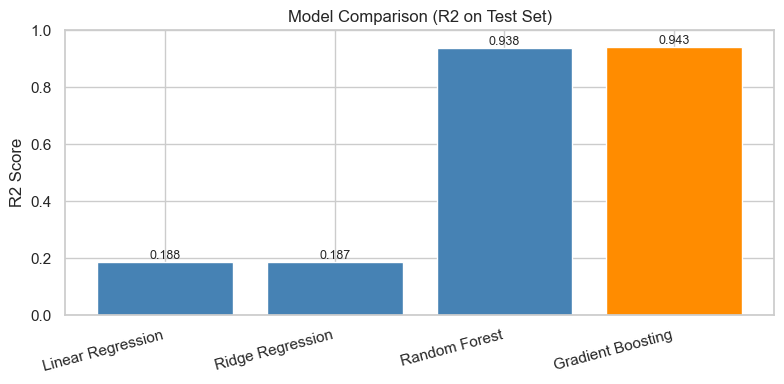

Best model: Gradient Boosting


In [13]:
# Model comparison bar chart
best_name = max(results, key=lambda k: results[k]['R2'])
names  = list(results.keys())
r2vals = [results[n]['R2'] for n in names]
colors = ['darkorange' if n == best_name else 'steelblue' for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, r2vals, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('R2 Score')
ax.set_title('Model Comparison (R2 on Test Set)')
for bar, val in zip(bars, r2vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.show()
print(f'Best model: {best_name}')

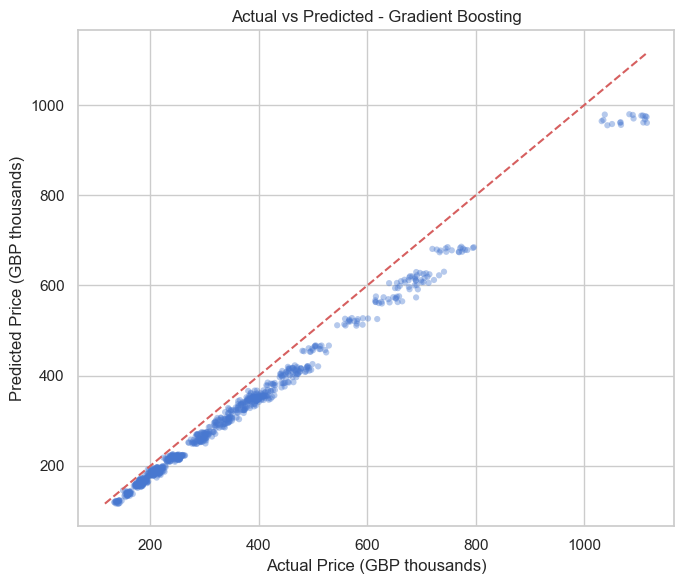

In [14]:
# Actual vs Predicted
best_preds = results[best_name]['preds']
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test / 1000, best_preds / 1000, alpha=0.4, edgecolors='none', s=20)
mn = min(y_test.min(), best_preds.min()) / 1000
mx = max(y_test.max(), best_preds.max()) / 1000
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
ax.set_xlabel('Actual Price (GBP thousands)')
ax.set_ylabel('Predicted Price (GBP thousands)')
ax.set_title(f'Actual vs Predicted - {best_name}')
plt.tight_layout()
plt.savefig('outputs/actual_vs_predicted.png', dpi=150)
plt.show()

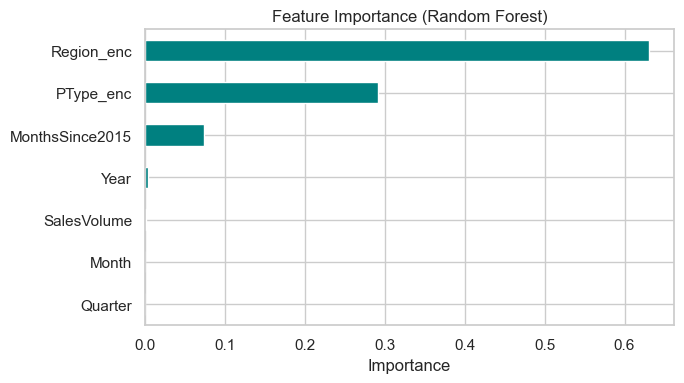

In [15]:
# Feature importance (Random Forest)
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
feat_imp.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150)
plt.show()

## 8. Predict New Values

In [16]:
best_model = results[best_name]['model']

def predict_price(year, month, region, property_type, sales_volume=500):
    """Predict average house price using the best trained model."""
    region_enc   = le_region.transform([region])[0]
    ptype_enc    = le_ptype.transform([property_type])[0]
    months_since = (year - 2015) * 12 + month
    quarter      = ((month - 1) // 3) + 1
    row = pd.DataFrame([{
        'Year': year, 'Month': month, 'Quarter': quarter,
        'MonthsSince2015': months_since,
        'Region_enc': region_enc, 'PType_enc': ptype_enc,
        'SalesVolume': sales_volume,
    }])
    return best_model.predict(row)[0]

print(f'Using model: {best_name}\n')

cases = [
    (2025, 6,  'London',        'Detached',     600),
    (2025, 6,  'London',        'Flat',          800),
    (2025, 6,  'North East',    'Terraced',      400),
    (2025, 6,  'South East',    'Semi-Detached', 500),
    (2025, 6,  'Scotland',      'Flat',          350),
    (2025, 12, 'London',        'Detached',      550),
    (2026, 6,  'London',        'Detached',      600),
    (2026, 6,  'North East',    'Flat',          300),
]

pred_df = pd.DataFrame(cases, columns=['Year','Month','Region','PropertyType','SalesVolume'])
pred_df['PredictedPrice_GBP'] = [
    predict_price(yr, mo, reg, pt, vol)
    for yr, mo, reg, pt, vol in cases
]
pred_df['PredictedPrice_GBP'] = pred_df['PredictedPrice_GBP'].map('GBP {:,.0f}'.format)
pred_df

Using model: Gradient Boosting



,Year,Month,Region,PropertyType,SalesVolume,PredictedPrice_GBP
0,2025,6,London,Detached,600,"GBP 974,793"
1,2025,6,London,Flat,800,"GBP 465,580"
2,2025,6,North East,Terraced,400,"GBP 143,207"
3,2025,6,South East,Semi-Detached,500,"GBP 419,609"
4,2025,6,Scotland,Flat,350,"GBP 163,913"
5,2025,12,London,Detached,550,"GBP 956,204"
6,2026,6,London,Detached,600,"GBP 974,793"
7,2026,6,North East,Flat,300,"GBP 122,842"


## 9. Error Analysis

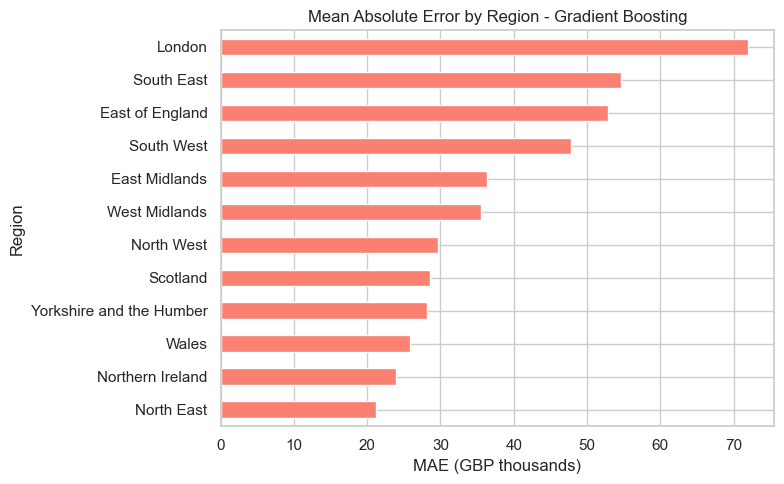


MAE by Region (GBP):
Region
North East                  GBP 21,200
Northern Ireland            GBP 23,864
Wales                       GBP 25,874
Yorkshire and the Humber    GBP 28,185
Scotland                    GBP 28,589
North West                  GBP 29,682
West Midlands               GBP 35,594
East Midlands               GBP 36,305
South West                  GBP 47,836
East of England             GBP 52,903
South East                  GBP 54,635
London                      GBP 71,909


In [17]:
# Residuals by region
test_df = df[~train_mask].copy()
test_df['Predicted'] = best_preds
test_df['Residual']  = test_df['AveragePrice_GBP'] - test_df['Predicted']
test_df['AbsError']  = test_df['Residual'].abs()

region_errors = test_df.groupby('Region')['AbsError'].mean().sort_values(ascending=True) / 1000
fig, ax = plt.subplots(figsize=(8, 5))
region_errors.plot(kind='barh', ax=ax, color='salmon')
ax.set_title(f'Mean Absolute Error by Region - {best_name}')
ax.set_xlabel('MAE (GBP thousands)')
plt.tight_layout()
plt.show()

print('\nMAE by Region (GBP):')
print((region_errors * 1000).map('GBP {:,.0f}'.format).to_string())

In [18]:
print('Notebook complete. All outputs saved to outputs/')

Notebook complete. All outputs saved to outputs/
